<a href="https://colab.research.google.com/github/Goutham-26/DSA/blob/main/Case_Study_on_Supervised_Learning_Final_17_08_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/train.csv")
data.head()

,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [3]:
data.duplicated().sum()

np.int64(0)

In [4]:
data.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [5]:
data['peso'].fillna(data['peso'].mean(), inplace=True)
data.isnull().sum()

/tmp/ipykernel_2085/3152814043.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['peso'].fillna(data['peso'].mean(), inplace=True)


,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [6]:
data['sexo'] = data['sexo'].map({'H': 0, 'M': 1})
print("Value counts for 'sexo' after mapping:")
print(data['sexo'].value_counts())
print("\nDataFrame info after 'sexo' mapping:")
data.info()

Value counts for 'sexo' after mapping:
sexo
0    57
1    37
Name: count, dtype: int64

DataFrame info after 'sexo' mapping:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     int64  
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              94 non-null     float64
dtypes: float64(12), 

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     int64  
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              94 non-null     float64
dtypes: float64(12), int64(1), object(1)
memory usage: 10.4+ KB


In [8]:
numerical_cols = data.select_dtypes(include=np.number).columns

outlier_counts = {}

for column in numerical_cols:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    outlier_counts[column] = len(outliers)

print("Number of outliers per numerical column (using IQR method):")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

Number of outliers per numerical column (using IQR method):
sexo: 0
longitudCraneo: 0
longitudPico: 0
longitudNarina: 0
anchoCraneo: 0
altoPico: 0
anchoPico: 2
tarso: 2
longAlaCerrada: 2
longAlaAbierta: 1
mediaEnvergadura: 1
envergadura: 1
peso: 2


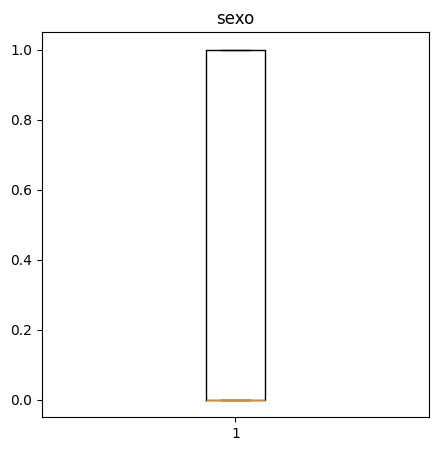

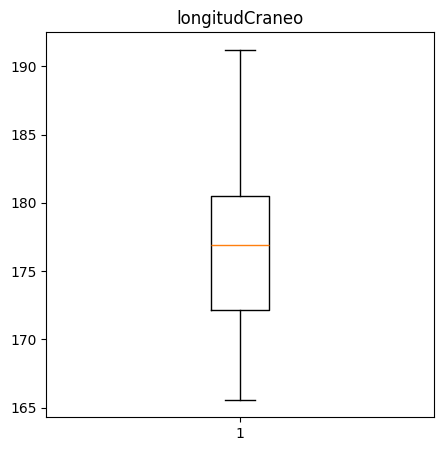

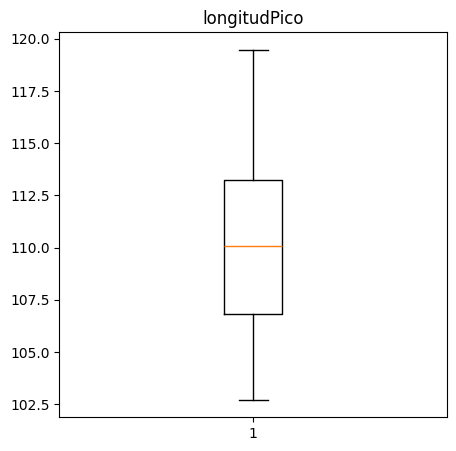

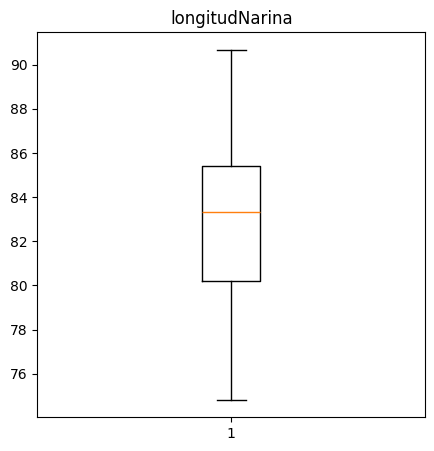

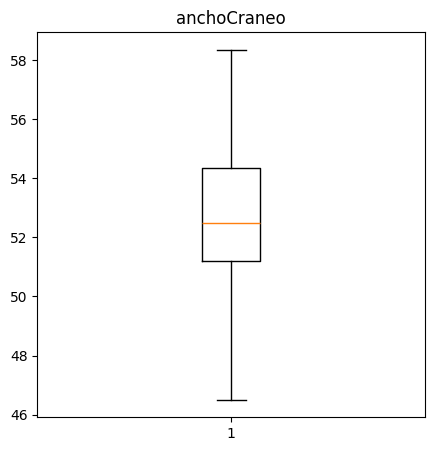

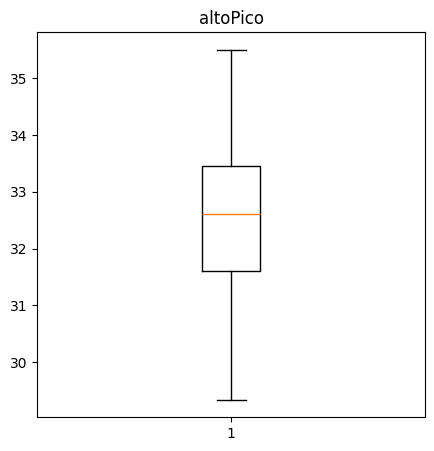

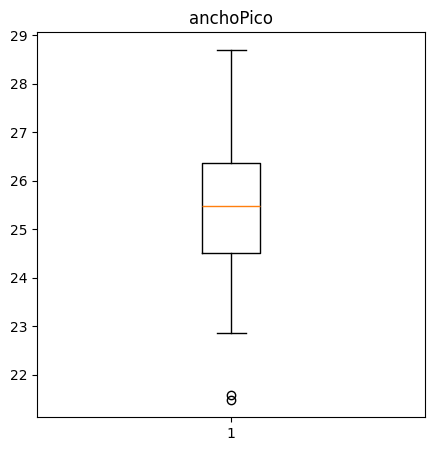

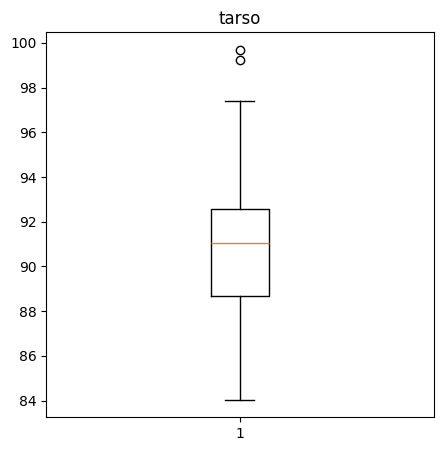

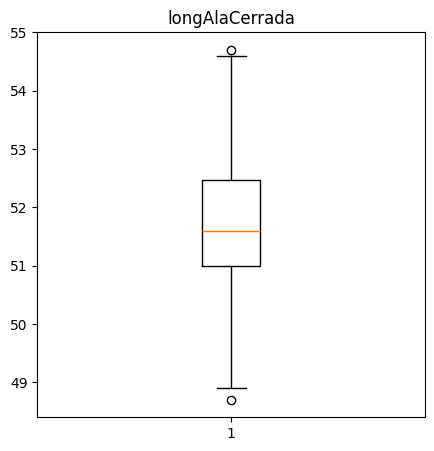

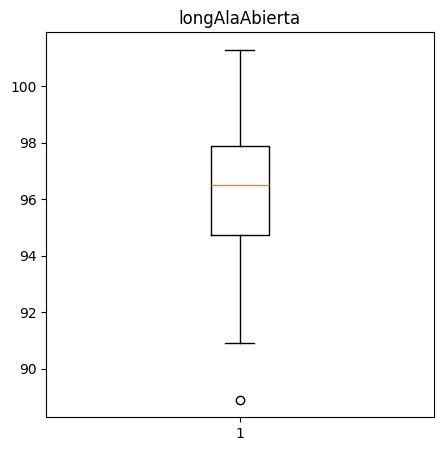

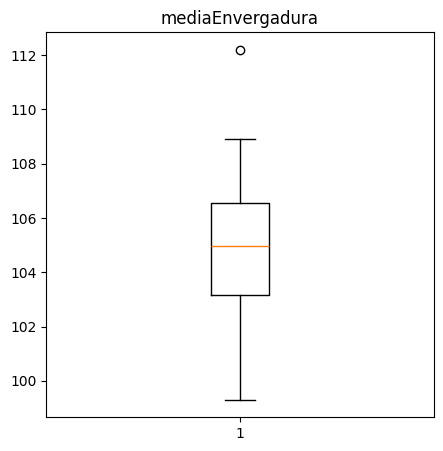

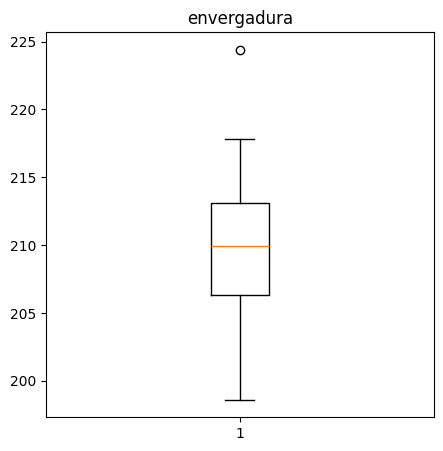

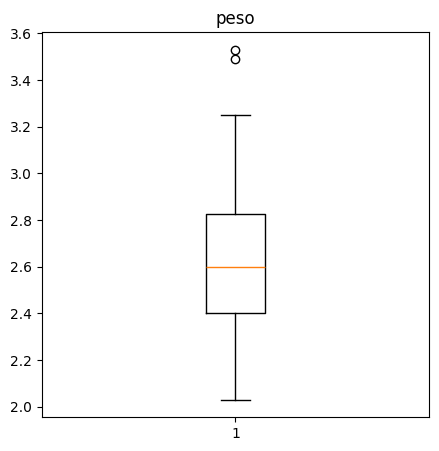

In [9]:
for i in numerical_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(data[i])
  plt.title(i)

In [10]:
y = data['sexo']

x = data.drop(columns=['sexo'])

In [11]:
x.columns

Index(['id', 'longitudCraneo', 'longitudPico', 'longitudNarina', 'anchoCraneo',
       'altoPico', 'anchoPico', 'tarso', 'longAlaCerrada', 'longAlaAbierta',
       'mediaEnvergadura', 'envergadura', 'peso'],
      dtype='object')

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler

x_train_scaled = x_train.drop(columns=['id'])
x_test_scaled = x_test.drop(columns=['id'])

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_scaled)

x_test_scaled = scaler.transform(x_test_scaled)

print("Shape of scaled x_train:", x_train_scaled.shape)
print("Shape of scaled x_test:", x_test_scaled.shape)


Shape of scaled x_train: (75, 12)
Shape of scaled x_test: (19, 12)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

log_reg_model = LogisticRegression(random_state=42)

log_reg_model.fit(x_train_scaled, y_train)

y_pred = log_reg_model.predict(x_test_scaled)

print("Logistic Regression Model Evaluation:")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Model Evaluation:

Accuracy: 0.7894736842105263

Confusion Matrix:
 [[8 2]
 [2 7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.78      0.78      0.78         9

    accuracy                           0.79        19
   macro avg       0.79      0.79      0.79        19
weighted avg       0.79      0.79      0.79        19



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train_scaled, y_train)

y_pred_rf = rf_model.predict(x_test_scaled)

print("RandomForestClassifier Model Evaluation:")
print("\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

RandomForestClassifier Model Evaluation:

Accuracy: 0.7368421052631579

Confusion Matrix:
 [[8 2]
 [3 6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.75      0.67      0.71         9

    accuracy                           0.74        19
   macro avg       0.74      0.73      0.73        19
weighted avg       0.74      0.74      0.74        19



Test


In [16]:
test = pd.read_csv("/content/test.csv")
test.head()


,id,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,A70_2018,183.57,117.18,87.90,53.60,33.10,26.50,95.70,52.5,98.6,104.4,208.8,3.35
1,5C9_2018,166.60,105.05,80.63,51.64,31.31,26.10,88.82,50.7,93.4,101.4,202.8,2.43
2,5E1_2018,175.53,111.23,84.93,53.74,32.75,24.93,91.42,51.3,94.2,103.4,206.8,2.99
3,C58_2018,187.85,116.90,87.52,54.22,35.10,27.00,99.48,52.3,99.8,107.6,215.2,3.55
4,5E2_2018,182.67,116.40,87.24,54.57,33.59,25.40,96.43,53.4,100.3,110.1,220.2,3.06


In [17]:
test_id = test['id']
test.drop(columns=['id'], inplace=True)

In [18]:
test.isnull().sum()

,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0
longAlaAbierta,0
mediaEnvergadura,0


In [19]:

test_scaled = scaler.transform(test)

print("Shape of scaled test data:", test_scaled.shape)

Shape of scaled test data: (41, 12)


In [20]:
predictions = log_reg_model.predict(test_scaled)

prediction_df = pd.DataFrame({'id': test_id, 'predicted_sexo': predictions})

print("Predicted 'sexo' for the test data:")
display(prediction_df.head())

Predicted 'sexo' for the test data:


,id,predicted_sexo
0,A70_2018,1
1,5C9_2018,0
2,5E1_2018,0
3,C58_2018,1
4,5E2_2018,1


In [21]:
predictions_rf = rf_model.predict(test_scaled)

prediction_df_rf = pd.DataFrame({'id': test_id, 'sexo': predictions_rf})

print("New predicted 'sexo' for the test data using RandomForest:")
display(prediction_df_rf.head())

New predicted 'sexo' for the test data using RandomForest:


,id,sexo
0,A70_2018,1
1,5C9_2018,0
2,5E1_2018,0
3,C58_2018,1
4,5E2_2018,1


In [22]:
predictions_lr = log_reg_model.predict(test_scaled)

predictions_lr = pd.Series(predictions_lr).map({0: "H", 1: "M"})

submission_pred = pd.DataFrame({
    "id": test_id,
    "sexo": predictions_lr
})

submission_pred.to_csv("submission_logistic_regression.csv", index=False)

display(submission_pred.head())

,id,sexo
0,A70_2018,M
1,5C9_2018,H
2,5E1_2018,H
3,C58_2018,M
4,5E2_2018,M


In [23]:
predictions_rf = rf_model.predict(test_scaled)

predictions_rf = pd.Series(predictions_rf).map({0: "H", 1: "M"})

submission_rf = pd.DataFrame({
    "id": test_id,
    "sexo": predictions_rf
})

submission_rf.to_csv("submission_random_forest.csv", index=False)

display(submission_rf.head())

,id,sexo
0,A70_2018,M
1,5C9_2018,H
2,5E1_2018,H
3,C58_2018,M
4,5E2_2018,M
